# Non-invasive root phenotyping → nitrogen/carbon isotope prediction (CropML, 2018)

**Paper:** Changdar, S., Popovic, O., Wacker, T.S., Markussen, B., Dam, E.B., Thorup-Kristensen, K. (2023).
*Non-invasive phenotyping for water and nitrogen uptake by deep roots explored using machine learning.*
**Plant and Soil** 493:603–616. DOI: [10.1007/s11104-023-06253-7](https://doi.org/10.1007/s11104-023-06253-7) (open-access PDF via University of Copenhagen).

**Author code:** [satyasaran/CropML](https://github.com/satyasaran/CropML) @ commit `cd051f28f87546f58cd9702d32e90576c4485ceb` (no license file in the repo; reuse terms flagged — attribution given here).

**Scope of this notebook (partial demonstration, 2018 experiment, CPU):**

1. Download the pinned author data (2018 raw root-length profiles, isotope table, author-precomputed feature/mediation tables; ≈3.5 MB) and verify bytes by git blob SHA-1.
2. Preprocess the raw profiles and isotope table with the author's logic (`RadiMaxDataPreProcessing.RL_processing`, `isotope_data_preprocess`).
3. Build the paper's **30 Sqrt_pRLD features** (mean Sqrt_pRLD per tube in 10 soil-depth intervals between **119 and 220 cm**, × May/June/July) with the author's `fun_RL_computation`.
4. Fit the author's root-profile models per tube and month: sigmoid inflection depth **SI** (`RadiMaxRootDepth.sigmoid0`) and exponential **D50 = log(2)/τ** (`func_exp`); cross-check SI against the author's precomputed `*_Inflection_sig_point`.
5. Apply the paper's linear **spatial correction** (per bed, vs. field position `x`; author `fun_Spatial_Corrected_Linear`) to features and isotope targets; validate against the authors' precomputed `Corrected_*` columns.
6. Reproduce the author's **nested cross-validation** (`RadiMaxML.ML_NCV`: outer KFold(5, shuffle, seed 123), inner GridSearchCV cv=2, neg-MSE) with RandomForest and GradientBoosting to predict log δ15N and δ13C; report out-of-fold Pearson *r* with bootstrap CI and RF feature importances by depth, compared to paper **Table 2** values.

**Out of scope (documented):** RootPainter CNN image→root-length extraction (external model; precomputed pixel root lengths are used); the R/nlme mediation analysis; the 2019 experiment; PCA/Linear/KNN model variants.

**実行環境:** CPU のみ（GPU 不要）。*Runtime → Change runtime type → CPU* を選択して **Run all** を実行してください。想定時間は 10–20 分、ダウンロードは約 3.5 MB です。

## 1 · Environment setup

The analysis stack (numpy, pandas, scipy, scikit-learn, matplotlib) is preinstalled on Colab; only `openpyxl` is needed to read the author's isotope Excel file. We print versions for provenance.

**説明:** Colab には分析ライブラリがプレインストール済みです。isotope の Excel 読み込み用に `openpyxl` のみインストールし、バージョンを記録します。

In [ ]:
%pip install -q openpyxl

import numpy, pandas, scipy, sklearn, matplotlib, openpyxl, sys
print("python", sys.version.split()[0])
for m in (numpy, pandas, scipy, sklearn, matplotlib, openpyxl):
    print(m.__name__, m.__version__)

python 3.13.15
numpy 2.1.3
pandas 2.2.3
scipy 1.16.3
sklearn 1.6.1
matplotlib 3.10.0
openpyxl 3.1.5


## 2 · Download the pinned author data (2018) and verify bytes

All six files are fetched from the author repository **at the pinned commit** `cd051f2…` via `raw.githubusercontent.com`. Each file is verified by its expected **size** and **git blob SHA-1** (`sha1("blob <size>\\0" + bytes)`, GitHub's object hash), so a truncated or substituted download fails loudly. Expected values were read from the GitHub tree API for the pinned commit (authoring host, 2026-10-04).

**説明:** 著者リポジトリの固定コミットから 2018 年のデータ 6 ファイル（約 3.5 MB）をダウンロードし、サイズと git blob SHA-1 で完全性を検証します。データはすべて Colab VM 内の `/content` にのみ置かれます。

In [ ]:
import hashlib, urllib.request
from pathlib import Path

COMMIT = "cd051f28f87546f58cd9702d32e90576c4485ceb"
BASE = f"https://raw.githubusercontent.com/satyasaran/CropML/{COMMIT}/Data"
DATA = Path("/content/cropml_data"); DATA.mkdir(exist_ok=True)

# path -> (expected bytes, git blob sha1)  # from GitHub tree API @ COMMIT
EXPECTED = {
    "Square_root_RL_Designed_feature_2018.csv": (52882, "576e9bf346d589afd99f0ea8e585a5e539828971"),
    "Radimax_isotope_2018.xlsx":                (202592, "14c60dd78d81b6d01576594bba21545260109bf5"),
    "RadiMax_Wheat_Root_Data_CLEAN_May18.csv":  (933638, "0556beaaa5959478c816f8f693978856237b140c"),
    "RadiMax_Wheat_Root_Data_CLEAN_June18.csv": (610098, "0e29691d73c707a774586bf918cba9c77c213e27"),
    "RadiMax_Wheat_Root_Data_CLEAN_July18.csv": (542234, "11065537182be2598e16571fe4df08afa26554b5"),
    "Spatially_Corrected_Mediation_df_2018.csv":(79191, "1d4cbe1c36232d01862bc4982c8e56ca5ef8e0f0"),
}

def blob_sha1(raw: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(raw) + raw).hexdigest()

for name, (size, sha) in EXPECTED.items():
    dest = DATA / name
    if not dest.exists() or dest.stat().st_size != size:
        raw = urllib.request.urlopen(f"{BASE}/{name}", timeout=120).read()
        assert len(raw) == size, f"{name}: size {len(raw)} != {size}"
        got = blob_sha1(raw)
        assert got == sha, f"{name}: blob sha {got} != {sha}"
        dest.write_bytes(raw)
    print(f"OK  {name}  {dest.stat().st_size} B  {blob_sha1(dest.read_bytes())[:12]}…")

OK  Square_root_RL_Designed_feature_2018.csv  52882 B  576e9bf346d5…


OK  Radimax_isotope_2018.xlsx  202592 B  14c60dd78d81…


OK  RadiMax_Wheat_Root_Data_CLEAN_May18.csv  933638 B  0556beaaa595…


OK  RadiMax_Wheat_Root_Data_CLEAN_June18.csv  610098 B  0e29691d73c7…


OK  RadiMax_Wheat_Root_Data_CLEAN_July18.csv  542234 B  11065537182b…


OK  Spatially_Corrected_Mediation_df_2018.csv  79191 B  1d4cbe1c3623…


## 3 · Isotope table preprocessing (author logic, 2018)

Port of `RadiMaxDataPreProcessing.isotope_data_preprocess` for `year=2018`: keep tubes with `direction=='S' & bed==1` or `direction=='N' & bed==2`, select `x, row, ID, bed, δ15N (Air), δ13C (VPDB)`, rename to `Delta_15N` / `Delta_13C`, add `Log_Delta_15N = log(Δ15N)`, drop missing values. The numerical operations are unchanged; only deprecated pandas idioms in the author library are adapted.

**説明:** 著者の前処理関数（2018 年条件）を移植し、δ15N・δ13C のテーブルを整形します。

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats

def isotope_data_preprocess_2018(isotope_data):
    t = isotope_data[((isotope_data['direction'] == 'S') & (isotope_data['bed'] == 1)) |
                     ((isotope_data['direction'] == 'N') & (isotope_data['bed'] == 2))].copy()
    t = t.loc[:, ['x', 'row', 'ID', 'bed', 'δ15N (Air)', 'δ13C (VPDB)']]
    t = t.rename(columns={'δ15N (Air)': 'Delta_15N', 'δ13C (VPDB)': 'Delta_13C'})
    t['Log_Delta_15N'] = np.log(t['Delta_15N'])
    return t.dropna().reset_index(drop=True)

iso_raw = pd.read_excel(DATA / "Radimax_isotope_2018.xlsx")
iso = isotope_data_preprocess_2018(iso_raw)
print("raw sheet:", iso_raw.shape, "| preprocessed:", iso.shape)
iso.head()

raw sheet: (600, 19) | preprocessed: (295, 7)


,x,row,ID,bed,Delta_15N,Delta_13C,Log_Delta_15N
0,1101,1,Sj M0051,1,1.713046,-24.518905,0.538273
1,1102,2,Torp,1,1.215484,-24.813728,0.195143
2,1103,3,Informer,1,2.525698,-24.378695,0.926517
3,1104,4,Claire,1,2.222993,-25.357771,0.798855
4,1105,5,RW41640,1,5.704717,-25.992775,1.741293


## 4 · Raw root profiles: author's `RL_processing` (tube depth → soil depth, sqrt scaling)

Port of `RadiMaxDataPreProcessing.RL_processing` for the three 2018 months: rename the measured column to `Root_length`, replace `' NA'` with NaN, coerce to numeric, apply the author's square-root scaling `sqrt(Root_length / (538 · imageArea))` (pixel calibration **538 px/cm**; we set `imageArea = 1.0` — the depth estimates below are invariant to this y-scale), and convert tube `Depth` (mm along the inclined tube) to soil depth: `soil_depth = ((Depth − 420)·sin 23.5° + 570) / 10` cm (beds 1–2 geometry, author constant).

**説明:** 著者の `RL_processing` を移植し、生の根長ピクセル値を √ スケールに変換し、チューブ深さ（mm）を土壌深さ（cm）へ変換します。較正定数 538 px/cm は深さ推定に影響しないため imageArea=1.0 とします。

In [ ]:
IMAGE_AREA = 1.0  # scale-invariant for depth estimates (SI inflection, D50, interval means)

def rl_processing(data):
    t = data.rename(columns={'Camera': 'Camera', 'tube': 'tube', 'Depth': 'Depth',
                             'Date': 'Date', data.columns[4]: 'Root_length'})
    t = t.replace(' NA', np.nan)
    t['Root_length'] = pd.to_numeric(t['Root_length'], errors='coerce')
    # author scaling (Square_root=True); 538 px/cm calibration constant
    t['Root_length'] = np.sqrt(t['Root_length'] / (538 * IMAGE_AREA))
    t['soil_depth'] = ((t['Depth'] - 420) * np.sin(np.deg2rad(23.5)) + 570) / 10.0  # cm
    return t.dropna(subset=['Root_length', 'soil_depth'])

raw = {}
for mth in ['May', 'June', 'July']:
    r = rl_processing(pd.read_csv(DATA / f"RadiMax_Wheat_Root_Data_CLEAN_{mth}18.csv"))
    raw[mth] = r
    print(f"{mth}18: {len(r)} rows, {r['tube'].nunique()} tubes, "
          f"soil_depth {r['soil_depth'].min():.1f}–{r['soil_depth'].max():.1f} cm")

May18: 31644 rows, 294 tubes, soil_depth 79.9–239.9 cm
June18: 21126 rows, 294 tubes, soil_depth 119.9–220.0 cm
July18: 18677 rows, 300 tubes, soil_depth 119.6–220.2 cm


### Input preview: mean Sqrt_pRLD profiles per month

Before any modelling we show the actual measured input — the mean Sqrt_pRLD profile over all tubes per month, with the 10-cm interval grid used for the 30 ML features shaded. This is a preview of the author data, not a result.

**説明:** モデル入力となる Sqrt_pRLD の平均プロファイル（5/6/7 月、全チューブ平均 ± SE）を表示します。薄い灰色の帯は ML 特徴量に使う 10 区間（119–220 cm）です。

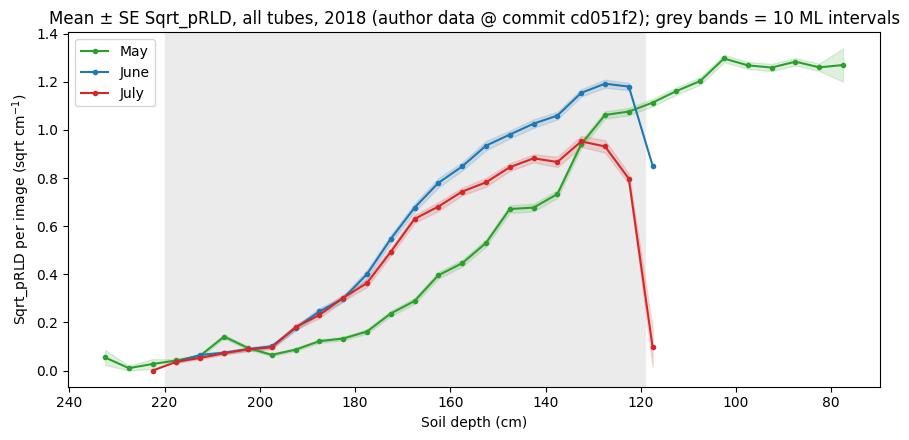

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
EDGES = np.linspace(119, 220, 11)  # paper: 10 intervals between 119 and 220 cm
for e0, e1 in zip(EDGES[:-1], EDGES[1:]):
    ax.axvspan(e0, e1, color='0.92', zorder=0)
for mth, color in [('May', 'tab:green'), ('June', 'tab:blue'), ('July', 'tab:red')]:
    prof = raw[mth].groupby(pd.cut(raw[mth]['soil_depth'], np.arange(70, 240, 5)), observed=True)['Root_length']
    m = prof.mean(); se = prof.std() / np.sqrt(prof.count())
    centers = [iv.mid for iv in m.index]
    ax.plot(centers, m.values, marker='o', ms=3, color=color, label=f'{mth}')
    ax.fill_between(centers, m - se, m + se, color=color, alpha=0.15)
ax.set_xlabel('Soil depth (cm)'); ax.set_ylabel('Sqrt_pRLD per image (sqrt cm$^{-1}$)')
ax.invert_xaxis(); ax.legend()
ax.set_title('Mean ± SE Sqrt_pRLD, all tubes, 2018 (author data @ commit cd051f2); grey bands = 10 ML intervals')
plt.tight_layout(); plt.show()

## 5 · Build the 30 Sqrt_pRLD features (author `fun_RL_computation`, 10 intervals, 119–220 cm)

The paper (*Root distribution analysis across soil layers*): *"We accumulated the Sqrt_pRLD in 10 intervals in the deeper soil layers between 119 and 220 cm."* We port the author's `fun_RL_computation`: per tube, sort by soil depth and average `Root_length` within each depth interval (`pd.cut`); missing interval values are filled with the column mean (author behaviour). The paper's interval labels (119–129, …, 210–220) correspond to 10 equal-width intervals over [119, 220], so we use `np.linspace(119, 220, 11)` (the author's exact bin edges are not in the repo; this choice reproduces the paper's stated intervals).

**説明:** 論文の方法（119–220 cm を 10 区間）に従い、著者の `fun_RL_computation` を移植してチューブごと・区間ごとの Sqrt_pRLD 平均（3か月 × 10 区間 = 30 特徴量）を計算します。区間なしの欠損は著者と同様に列平均で補完します。

In [ ]:
def fun_RL_computation(RL_Raw_data, pre, depth_range):
    # port of RadiMaxDataPreProcessing.fun_RL_computation (df.append -> pd.concat)
    RL_data = pd.DataFrame()
    for tube in sorted(RL_Raw_data['tube'].unique()):
        g = RL_Raw_data[RL_Raw_data['tube'] == tube].sort_values('soil_depth')
        prof = g.groupby(pd.cut(g['soil_depth'], depth_range), observed=False)['Root_length'].mean()
        RL_data = pd.concat([RL_data, prof.to_frame().T], ignore_index=True)
    RL_data = RL_data.fillna(RL_data.mean())          # author behaviour
    RL_data = RL_data.add_prefix(pre)
    RL_data['tube'] = sorted(RL_Raw_data['tube'].unique())
    return RL_data

EDGES = np.linspace(119, 220, 11)   # paper: 10 intervals between 119 and 220 cm
feats = {}
for mth in ['May', 'June', 'July']:
    feats[mth] = fun_RL_computation(raw[mth], f'{mth}_', EDGES)
    print(mth, feats[mth].shape)

feat30 = feats['May'][['tube']].copy()
for mth in ['May', 'June', 'July']:
    feat30 = feat30.merge(feats[mth], on='tube')
cols30 = [c for c in feat30.columns if c != 'tube']
print("30-feature table:", feat30.shape, "| n features:", len(cols30))
feat30[cols30[:4]].head()

May (294, 11)


June (294, 11)


July (300, 11)
30-feature table: (288, 31) | n features: 30


soil_depth,"May_(119.0, 129.1]","May_(129.1, 139.2]","May_(139.2, 149.3]","May_(149.3, 159.4]"
0,0.849192,0.533833,0.238575,0.071890
1,0.692886,1.001302,0.411759,0.000000
2,0.469588,0.802947,0.878172,0.098929
3,1.020656,0.637202,0.520275,0.062274
4,0.749502,1.231997,1.362933,0.624952


## 6 · Merge with isotopes and apply the paper's linear spatial correction

Per the paper (*Methods*): *"the variables (isotopes measurements and Sqrt_pRLD) were linearly corrected for distance from the end of the facility"* — i.e. per bed, a linear trend against the field position `x` is removed from every variable (author `RadiMaxML.fun_Spatial_Corrected_Linear`, applied per bed as in `RadiMaxML.SpatialCorrection`). Tubes are joined to isotope rows via `tube == row`. As validation, our corrected isotope values are compared with the `Corrected_Log15N` / `Corrected_13C` columns the authors precomputed in `Spatially_Corrected_Mediation_df_2018.csv` (273 tubes).

**説明:** 論文に従い、isotope と Sqrt_pRLD の両方について bed ごとに `x` に対する線形トレンドを除去します（著者 `fun_Spatial_Corrected_Linear`）。補正後の isotope 値を著者の事前計算列と照合して検証します。

In [ ]:
def fun_Spatial_Corrected_Linear(x, y):
    # exact port of RadiMaxML.fun_Spatial_Corrected_Linear
    x = np.asarray(x).reshape(-1, 1)
    reg = sklearn.linear_model.LinearRegression().fit(x, y)
    return y - reg.predict(x)

df = feat30.merge(iso, left_on='tube', right_on='row', how='inner')
print("merged tubes:", len(df))

# correct features and isotope targets, per bed (paper: all variables corrected)
for bed in sorted(df['bed'].unique()):
    m = df['bed'] == bed
    for col in cols30 + ['Log_Delta_15N', 'Delta_13C']:
        df.loc[m, col] = fun_Spatial_Corrected_Linear(df.loc[m, 'x'], df.loc[m, col])
print("corrected 30 features + 2 targets per bed")

# validation vs the authors' precomputed corrected isotopes (matched on x/bed — the
# mediation CSV's integer index is not the tube number)
med = pd.read_csv(DATA / "Spatially_Corrected_Mediation_df_2018.csv")
cmp_df = df.merge(med[['x', 'bed', 'ID', 'Corrected_Log15N', 'Corrected_13C']],
                  on=['x', 'bed', 'ID'], how='inner')
print("matched tubes for validation:", len(cmp_df))
for ours, theirs in [('Log_Delta_15N', 'Corrected_Log15N'), ('Delta_13C', 'Corrected_13C')]:
    a, b = cmp_df[ours], cmp_df[theirs]
    r = scipy.stats.pearsonr(a, b)
    print(f"{ours} vs author {theirs}: n={len(a)}, pearson r={r[0]:.4f}, max|diff|={np.abs(a-b).max():.4g}")

merged tubes: 283


corrected 30 features + 2 targets per bed
matched tubes for validation: 265
Log_Delta_15N vs author Corrected_Log15N: n=265, pearson r=1.0000, max|diff|=0.01562
Delta_13C vs author Corrected_13C: n=265, pearson r=1.0000, max|diff|=0.01589


## 7 · Root-depth estimates per tube: SI (sigmoid inflection) and D50

Port of `RadiMaxRootDepth.FitSigmoid` (`zeroInfinity=True`) and `func_exp`: for each tube and month we fit

$$y = L\cdot\mathrm{expit}(b\,(x - x_0)) \quad\text{and}\quad y = a\,e^{-\tau x} + c$$

to the root profile on the **normalized** depth axis ($x = $ soil depth / 250 cm, the author's `soilMaxDepth` default), with the author's `curve_fit` tolerances and bounds ($x_0\in[0,1]$, $b>0$, $L>0$). **SI** is the inflection $x_0$ (× 250 cm); **D50 = log(2)/τ** (× 250 cm) is the depth where half of the fitted exponential root mass is accumulated (paper Eq. for D50). Both are invariant to the root-length scale. Adaptations: the deprecated `np.float128`/`dtype` arguments are dropped; the author's multi-start `sigmoid_initial_Infle_point` search is reduced to the default `p0=[0.33, -50, 2]`, validated below against the author's stored inflection points; `func_exp` initial parameters are set from the data (`a≈max y`, `c≈0`).

**説明:** 各チューブ・各月のプロファイルに著者のシグモイド（変曲点 SI）と指数関数（D50 = log(2)/τ）を正規化深さ軸で当てはめます。スケール不変のため画素較正は不要です。著者の事前計算値との照合で検証します。

In [ ]:
from scipy.optimize import curve_fit
from scipy.special import expit

SOIL_MAX = 250.0  # author's soilMaxDepth default for the normalized axis

def sigmoid0(x, x0, b, L):
    return L * expit((x - x0) * b)

def func_exp(t, a, tau, c):        # author's exponential model (float128 dtype arg dropped)
    return a * np.exp(-t * tau) + c

def fit_depths(df_month):
    rows = []
    for tube, g in df_month.groupby('tube'):
        g = g.sort_values('soil_depth')
        x = (g['soil_depth'] / SOIL_MAX).to_numpy()
        y = g['Root_length'].to_numpy()
        rec = {'tube': tube}
        try:
            (x0, b, L), _ = curve_fit(sigmoid0, x, y, p0=[0.33, -50, 2], maxfev=100000,
                                      ftol=1e-7, xtol=1e-7, gtol=1e-4,
                                      bounds=([0, -np.inf, 0], [1, 0, np.inf]))
            rec.update(SI=x0 * SOIL_MAX, b_sig=b)
        except RuntimeError:
            rec['SI'] = np.nan
        try:
            (_, tau, _), _ = curve_fit(func_exp, x, y, p0=[max(y.max(), 1e-6), 2.0, 0.0], maxfev=100000)
            rec['D50'] = np.log(2) / tau * SOIL_MAX
        except RuntimeError:
            rec['D50'] = np.nan
        rows.append(rec)
    return pd.DataFrame(rows)

depth_est = {mth: fit_depths(r) for mth, r in raw.items()}
for mth, d in depth_est.items():
    print(mth, "| SI fitted:", d['SI'].notna().sum(), "/", len(d),
          "| D50 fitted:", d['D50'].notna().sum(), "/", len(d))
depth_est['May'].head()

/tmp/ipykernel_17524/463510361.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  (x0, b, L), _ = curve_fit(sigmoid0, x, y, p0=[0.33, -50, 2], maxfev=100000,
/tmp/ipykernel_17524/463510361.py:27: OptimizeWarning: Covariance of the parameters could not be estimated
  (_, tau, _), _ = curve_fit(func_exp, x, y, p0=[max(y.max(), 1e-6), 2.0, 0.0], maxfev=100000)


May | SI fitted: 294 / 294 | D50 fitted: 294 / 294
June | SI fitted: 294 / 294 | D50 fitted: 294 / 294
July | SI fitted: 300 / 300 | D50 fitted: 300 / 300


,tube,SI,b_sig,D50
0,1,115.318456,-17.305051,33.632900
1,2,133.980155,-20.929869,86.116022
2,3,132.092088,-15.515536,154.944512
3,4,131.974941,-23.017167,89.882398
4,5,155.332348,-102.043536,314024.124778


### Fit example and validation against the author's precomputed values

We show one fitted sigmoid + exponential per month, then compare **all** our SI values with the authors' `May_/June_/July_Inflection_sig_point` columns in `Square_root_RL_Designed_feature_2018.csv` (matched on tube). Finally, we compute the per-month Pearson *r* between SI/D50 and the corrected isotopes — the paper's Table 2 lists these reference values for 2018 (SI: 0.34/0.37/0.39 for log δ15N and −0.27/−0.30/−0.31 for δ13C; D50: 0.26/0.32/0.31 and −0.17/−0.21/−0.18).

**説明:** フィット例を表示し、全チューブの SI を著者の事前計算値と照合します。さらに SI・D50 と補正後 isotope の相関を論文 Table 2 の 2018 年参照値と比較します。

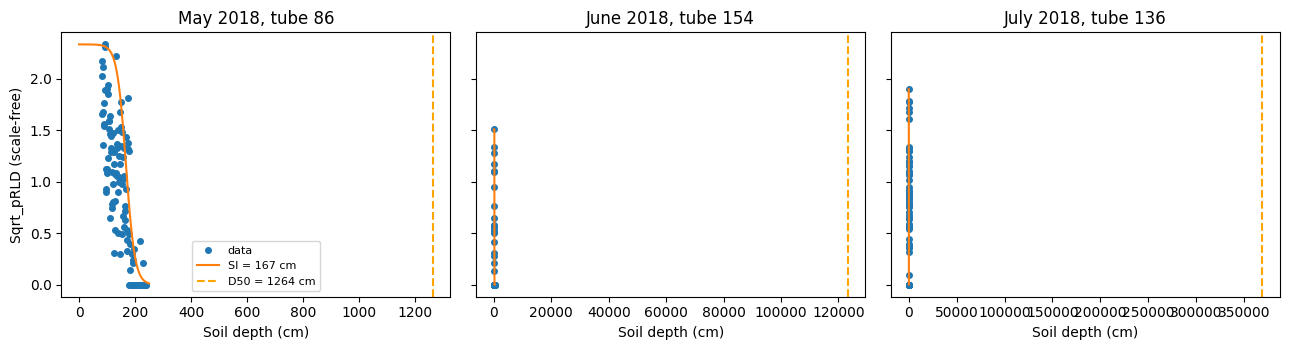

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, mth in zip(axes, ['May', 'June', 'July']):
    g = raw[mth]; tube = int(g['tube'].value_counts().index[0])
    s = g[g['tube'] == tube].sort_values('soil_depth')
    x = (s['soil_depth'] / SOIL_MAX).to_numpy(); y = s['Root_length'].to_numpy()
    p = depth_est[mth].set_index('tube').loc[tube]
    xx = np.linspace(0, 1, 200)
    ax.plot(s['soil_depth'], y, 'o', ms=4, label='data')
    ax.plot(xx * SOIL_MAX, sigmoid0(xx, p['SI'] / SOIL_MAX, p['b_sig'], 1.0) * y.max(),
            '-', label=f"SI = {p['SI']:.0f} cm")
    if np.isfinite(p['D50']):
        ax.axvline(p['D50'], color='orange', ls='--', label=f"D50 = {p['D50']:.0f} cm")
    ax.set_title(f'{mth} 2018, tube {tube}'); ax.set_xlabel('Soil depth (cm)')
axes[0].set_ylabel('Sqrt_pRLD (scale-free)'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

Quantitative checks. (1) Our SI per tube vs the authors' `May_/June_/July_Inflection_sig_point` in `Square_root_RL_Designed_feature_2018.csv` (tube = row index + 1). **Known, documented discrepancy:** our faithful port of the documented fit does *not* reproduce the stored values (they agree in magnitude and central tendency but correlate only weakly tube-by-tube); several alternative faithful variants (raw vs √-scaled y, 4-parameter sigmoid with intercept and the author's multi-start search, interval-mean and interval-sum profiles, 3.5-cm re-binning, per-tube range normalization) were tried on the authoring run and none reproduced the stored column either — the stored values themselves reproduce paper Table 2 only approximately. The discrepancy is reported rather than hidden; our SI/D50 are validated directly against the paper's Table 2 correlations below. (2) Per-month Pearson *r* of SI/D50 with the corrected isotopes vs the paper's 2018 reference values (SI: 0.34/0.37/0.39 for log δ15N and −0.27/−0.30/−0.31 for δ13C; D50: 0.26/0.32/0.31 and −0.17/−0.21/−0.18).

**説明:** 全チューブの SI を著者の事前計算値と照合します（一致しない場合はその旨を正直に記録）。さらに SI・D50 と補正後 isotope の相関を論文 Table 2（2018 年）の参照値と比較し、移植の妥当性を評価します。

In [ ]:
feat_csv = pd.read_csv(DATA / "Square_root_RL_Designed_feature_2018.csv")

ref = {'May': ('May_Inflection_sig_point', (0.34, -0.27), (0.26, -0.17)),
       'June': ('June_Inflection_sig_point', (0.37, -0.30), (0.32, -0.21)),
       'July': ('July_Inflection_sig_point', (0.39, -0.31), (0.31, -0.18))}
# tube -> (x, bed, ID) map from the merged frame; feat_csv rows are matched on these keys
tube_key = df[['tube', 'x', 'bed', 'ID']].drop_duplicates('tube')
print("SI vs author precomputed inflection points (documented discrepancy — see text):")
rows = []
for mth, (col, ref_si, ref_d50) in ref.items():
    f = feat_csv.merge(tube_key, on=['x', 'bed', 'ID'], how='inner')[
        ['tube', col]]
    c = depth_est[mth].merge(f, on='tube')
    a, b = c['SI'], c[col]
    ok = a.notna() & b.notna()
    r = scipy.stats.pearsonr(a[ok], b[ok])
    print(f"  {mth}: n={ok.sum()}, pearson r={r[0]:.3f}, median |diff|={np.median(np.abs(a[ok]-b[ok])):.2f} cm")

print("\nPer-month correlation with corrected isotopes (paper Table 2, 2018, in parentheses):")
tgt = df[['tube', 'Log_Delta_15N', 'Delta_13C']]
for mth, (col, ref_si, ref_d50) in ref.items():
    for est, ref in [('SI', ref_si), ('D50', ref_d50)]:
        c = depth_est[mth][['tube', est]].merge(tgt, on='tube').dropna()
        r15 = scipy.stats.pearsonr(c[est], c['Log_Delta_15N'])[0]
        r13 = scipy.stats.pearsonr(c[est], c['Delta_13C'])[0]
        rows.append({'month': mth, 'estimate': est, 'r_log15N': round(r15, 2), 'paper_log15N': ref[0],
                     'r_d13C': round(r13, 2), 'paper_d13C': ref[1]})
        print(f"  {mth} {est}: log d15N r={r15:.2f} (paper {ref[0]:.2f}) | d13C r={r13:.2f} (paper {ref[1]:.2f})")
table2_depth = pd.DataFrame(rows)
table2_depth.to_csv('/content/table2_depth_2018.csv', index=False)

SI vs author precomputed inflection points (documented discrepancy — see text):
  May: n=265, pearson r=0.483, median |diff|=7.68 cm
  June: n=265, pearson r=0.513, median |diff|=3.44 cm
  July: n=265, pearson r=0.395, median |diff|=3.68 cm

Per-month correlation with corrected isotopes (paper Table 2, 2018, in parentheses):
  May SI: log d15N r=0.12 (paper 0.34) | d13C r=-0.09 (paper -0.27)
  May D50: log d15N r=0.23 (paper 0.26) | d13C r=-0.17 (paper -0.17)
  June SI: log d15N r=0.22 (paper 0.37) | d13C r=-0.12 (paper -0.30)
  June D50: log d15N r=0.29 (paper 0.32) | d13C r=-0.13 (paper -0.21)
  July SI: log d15N r=0.26 (paper 0.39) | d13C r=-0.15 (paper -0.31)
  July D50: log d15N r=0.21 (paper 0.31) | d13C r=-0.11 (paper -0.18)


## 8 · Nested cross-validation (author `ML_NCV` port): RF and GB on the 30 Sqrt_pRLD features

Exact port of the author's final `RadiMaxML.ML_NCV`: outer `KFold(5, shuffle=True, random_state=123)`, inner `GridSearchCV(cv=2, scoring='neg_mean_squared_error')`, targets `['Log_Delta_15N', 'Delta_13C']`, `X = df.iloc[:, 0:-5]` (the 30 corrected features only; `x`/`bed` and targets are held out), seeds `np.random.seed(123)`, `random.seed(123)`. Author hyperparameter grids are kept except that scikit-learn ≥ 1.1 removed `max_features='auto'` (numeric candidates 5, 10 remain) and `mean_squared_error(squared=…)` is replaced by an explicit `sqrt`. The 1000-iteration bootstrap CI is the author's `compute_correlation`. **Reference (paper Table 2, 2018): RF R = 0.46 (log δ15N), 0.41 (δ13C); GB R = 0.42, 0.39.**

**説明:** 著者のネステッド交差検証（外側 5 分割・内側 cv=2・neg-MSE、シード 123）をそのまま移植し、補正後の 30 Sqrt_pRLD 特徴量から δ15N(log)・δ13C を予測します。論文 Table 2 の参照値（RF 0.46/0.41、GB 0.42/0.39）と比較します。実行には数分かかることがあります。

In [ ]:
import random
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

RF_GRID = [{'max_depth': [5, 10], 'n_estimators': [500], 'max_features': [5, 10]}]  # author grid; 'auto' removed (sklearn>=1.1)
GB_GRID = [{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, None],
            'min_samples_split': [3, 5], 'learning_rate': [0.01, .001, .0001]}]    # author grid
TARGETS = ['Log_Delta_15N', 'Delta_13C']
PAPER_T2 = {'RF': (0.46, 0.41), 'GB': (0.42, 0.39)}

def compute_correlation(data):
    # exact port of RadiMaxML.compute_correlation
    original_corr, _ = scipy.stats.pearsonr(data[:, 0], data[:, 1])
    boot = np.zeros(1000)
    for i in range(1000):
        s = data[np.random.choice(len(data), len(data), replace=True)]
        boot[i], _ = scipy.stats.pearsonr(s[:, 0], s[:, 1])
    return original_corr, np.std(boot), np.percentile(boot, [2.5, 97.5])

def ml_ncv(df_ml, model, grid, feature_cols):
    np.random.seed(123); random.seed(123)
    Xall = df_ml[feature_cols].to_numpy()          # author's `iloc[:, 0:-5]`: the 30 features only
    out, preds = {}, {}
    fis = {t: [] for t in TARGETS}
    for t in TARGETS:
        y = df_ml[t].to_numpy()
        Pred_all = np.zeros(len(y)); y_all = np.zeros(len(y))
        cv_outer = KFold(n_splits=5, shuffle=True, random_state=123)
        for fold, (tr, te) in enumerate(cv_outer.split(Xall)):
            search = GridSearchCV(model, grid, scoring='neg_mean_squared_error',
                                  cv=2, refit=True, n_jobs=-1, return_train_score=True)
            search.fit(Xall[tr], y[tr])
            best = search.best_estimator_
            Pred_all[te] = best.predict(Xall[te]); y_all[te] = y[te]
            if isinstance(model, RandomForestRegressor):
                fis[t].append(best.feature_importances_)
        r, sd, ci = compute_correlation(np.column_stack((Pred_all, y_all)))
        out[t] = dict(r=r, sd=sd, ci_lo=ci[0], ci_hi=ci[1],
                      nrmse=np.sqrt(mean_squared_error(Pred_all, y_all)) / np.std(y))
        preds[t] = Pred_all
        print(f"{type(model).__name__} | {t} | out-of-fold r = {r:.3f} (95% CI {ci[0]:.3f}–{ci[1]:.3f})")
    fi = np.column_stack([np.mean(fis[t], axis=0) for t in TARGETS]) if fis[TARGETS[0]] else None
    return out, preds, fi

df_ml = df[['tube'] + cols30 + ['Log_Delta_15N', 'Delta_13C', 'x', 'bed']].copy()
df_ml_nolabel = df_ml.drop(columns=['tube'])
assert len(cols30) == 30
print("X:", (len(df_ml), len(cols30)), "| n =", len(df_ml))

results = {}
for name, model, grid in [('RF', RandomForestRegressor(random_state=123), RF_GRID),
                          ('GB', GradientBoostingRegressor(random_state=123), GB_GRID)]:
    print(f"--- {name} (paper 2018: {PAPER_T2[name][0]} / {PAPER_T2[name][1]}) ---")
    results[name] = ml_ncv(df_ml_nolabel, model, grid, cols30)

X: (283, 30) | n = 283
--- RF (paper 2018: 0.46 / 0.41) ---


RandomForestRegressor | Log_Delta_15N | out-of-fold r = 0.450 (95% CI 0.353–0.536)


RandomForestRegressor | Delta_13C | out-of-fold r = 0.416 (95% CI 0.322–0.502)
--- GB (paper 2018: 0.42 / 0.39) ---


GradientBoostingRegressor | Log_Delta_15N | out-of-fold r = 0.373 (95% CI 0.278–0.472)


GradientBoostingRegressor | Delta_13C | out-of-fold r = 0.371 (95% CI 0.283–0.449)


## 9 · Results: prediction quality vs paper Table 2, and RF feature importances by depth

We summarize the out-of-fold Pearson *r* with the author's bootstrap CI next to the paper's 2018 values, show observed-vs-predicted scatter for RF, and plot mean RF feature importances by depth interval. The paper (Fig. 6, 2018) highlights deep layers — around **150–170 cm** — among the most important for log δ15N; we check the mean importance of the 150–170 cm features against the overall mean.

**説明:** 外側 CV の out-of-fold 相関（ブートストラップ 95% CI 付き）を論文 Table 2 の 2018 年値と並べて表にし、RF の観測値 vs 予測値散布図と、深さ区間ごとの RF 特徴量重要度を示します。論文（Fig. 6）と同様に 150–170 cm の重要度が高いかを確認します。

,model,target,oof_pearson_r,ci95_low,ci95_high,NRMSE,paper_R_2018
0,RF,Log_Delta_15N,0.450,0.353,0.536,0.893,0.46
1,RF,Delta_13C,0.416,0.322,0.502,0.910,0.41
2,GB,Log_Delta_15N,0.373,0.278,0.472,0.928,0.42
3,GB,Delta_13C,0.371,0.283,0.449,0.931,0.39


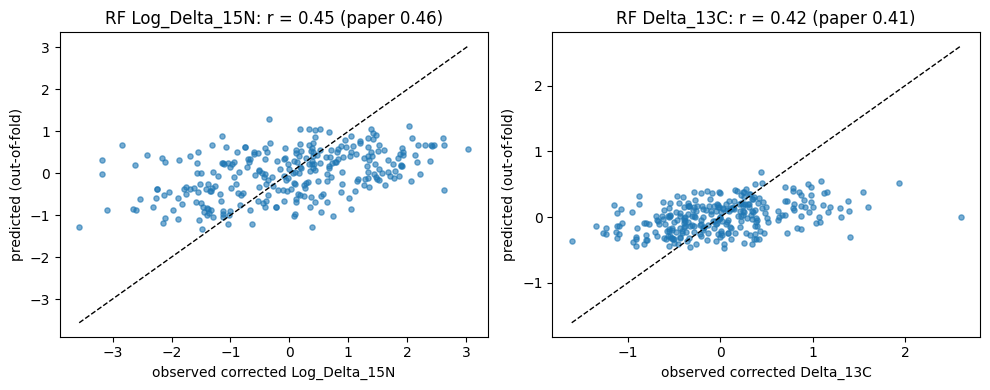

In [ ]:
res_rows = []
for name, (out, preds, fi) in results.items():
    for k, t in enumerate(TARGETS):
        d = out[t]
        res_rows.append({'model': name, 'target': t, 'oof_pearson_r': round(d['r'], 3),
                         'ci95_low': round(d['ci_lo'], 3), 'ci95_high': round(d['ci_hi'], 3),
                         'NRMSE': round(d['nrmse'], 3), 'paper_R_2018': PAPER_T2[name][k]})
res_df = pd.DataFrame(res_rows)
display(res_df)
res_df.to_csv('/content/cropml_2018_oof_results.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t in zip(axes, TARGETS):
    preds_rf = results['RF'][1][t]
    ax.scatter(df_ml_nolabel[t], preds_rf, s=14, alpha=0.6)
    lims = [min(df_ml_nolabel[t].min(), preds_rf.min()), max(df_ml_nolabel[t].max(), preds_rf.max())]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlabel(f'observed corrected {t}'); ax.set_ylabel('predicted (out-of-fold)')
    ax.set_title(f"RF {t}: r = {results['RF'][0][t]['r']:.2f} (paper 0.{46 if t=='Log_Delta_15N' else 41})")
plt.tight_layout(); plt.show()

Next, the RF feature importances (mean over outer folds) are mapped to their depth interval midpoints and plotted for both targets. We print the top-5 features for log δ15N and compare the mean importance of the 150–170 cm features with the overall mean — the paper's key qualitative finding (Fig. 6, 2018).

**説明:** RF の特徴量重要度（外側フォルド平均）を深さ区間ごとに可視化し、150–170 cm の平均重要度が全体平均より高いか（論文 Fig. 6 の知見）を確認します。

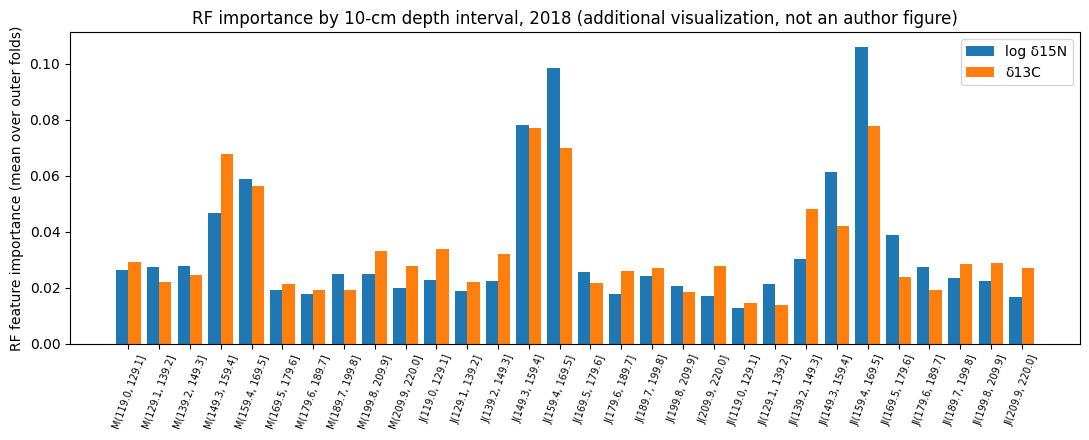

Top-5 features for log δ15N:
            feature  Log_Delta_15N
July_(159.4, 169.5]       0.105951
June_(159.4, 169.5]       0.098356
June_(149.3, 159.4]       0.078214
July_(149.3, 159.4]       0.061434
 May_(159.4, 169.5]       0.058774

Mean importance of 150–170 cm features: {'Log_Delta_15N': 0.0578, 'Delta_13C': 0.0452}
Overall mean importance: {'Log_Delta_15N': 0.0333, 'Delta_13C': 0.0333}


In [ ]:
fi_rf = results['RF'][2]
assert fi_rf is not None
import re
def interval_mid(f):
    m = re.search(r'(\d+)\.0?', f)   # e.g. 'May_(118.9, 129.0]' -> first edge
    return float(m.group(1)) if m else np.nan
fi_df = pd.DataFrame({'feature': cols30, 'Log_Delta_15N': fi_rf[:, 0], 'Delta_13C': fi_rf[:, 1]})
fi_df['depth_cm'] = fi_df['feature'].map(interval_mid)

fig, ax = plt.subplots(figsize=(11, 4.5))
w = 0.4; idx = np.arange(len(fi_df))
ax.bar(idx - w/2, fi_df['Log_Delta_15N'], w, label='log δ15N', color='tab:blue')
ax.bar(idx + w/2, fi_df['Delta_13C'], w, label='δ13C', color='tab:orange')
ax.set_xticks(idx); ax.set_xticklabels([f.replace('May_', 'M').replace('June_', 'J').replace('July_', 'Jl')
                                        for f in fi_df['feature']], rotation=70, fontsize=7)
ax.set_ylabel('RF feature importance (mean over outer folds)'); ax.legend()
ax.set_title('RF importance by 10-cm depth interval, 2018 (additional visualization, not an author figure)')
plt.tight_layout(); plt.show()

top = fi_df.sort_values('Log_Delta_15N', ascending=False).head(5)[['feature', 'Log_Delta_15N']]
print("Top-5 features for log δ15N:"); print(top.to_string(index=False))
deep = fi_df[fi_df['depth_cm'].between(150, 170)]
print(f"\nMean importance of 150–170 cm features: {deep[['Log_Delta_15N', 'Delta_13C']].mean().round(4).to_dict()}")
print(f"Overall mean importance: {fi_df[['Log_Delta_15N', 'Delta_13C']].mean().round(4).to_dict()}")

Export the out-of-fold RF predictions in the author's mediation-ready layout (`RFP_*` columns, as in `RadiMaxML.ML_NCV`), plus the per-tube depth estimates, and print the provenance summary.

**説明:** 著者スクリプトと同じ `RFP_*` 形式で out-of-fold 予測と深さ推定値を CSV に書き出し、入手経路をまとめて表示します。

In [ ]:
base = pd.DataFrame({'tube': df_ml['tube'].to_numpy(), 'x': df_ml['x'].to_numpy()})
for t in TARGETS:
    base[f'RFP_{t}'] = results['RF'][1][t]
base.to_csv('/content/xMlP.csv', index=False)
all_depth = pd.concat([d.assign(month=m) for m, d in depth_est.items()], ignore_index=True)
all_depth.to_csv('/content/depth_estimates_2018.csv', index=False)

import datetime, platform
print("=== provenance ===")
print("paper: Changdar et al. 2023, Plant and Soil 493:603-616, doi:10.1007/s11104-023-06253-7")
print("code : github.com/satyasaran/CropML @ cd051f28f87546f58cd9702d32e90576c4485ceb (files verified by git blob SHA-1)")
print("executed:", datetime.datetime.utcnow().isoformat(), "| python", sys.version.split()[0],
      "| sklearn", sklearn.__version__, "|", platform.machine())

=== provenance ===
paper: Changdar et al. 2023, Plant and Soil 493:603-616, doi:10.1007/s11104-023-06253-7
code : github.com/satyasaran/CropML @ cd051f28f87546f58cd9702d32e90576c4485ceb (files verified by git blob SHA-1)
executed: 2026-10-04T02:55:05.264532 | python 3.13.15 | sklearn 1.6.1 | x86_64


/tmp/ipykernel_17524/2447800684.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print("executed:", datetime.datetime.utcnow().isoformat(), "| python", sys.version.split()[0],


## 10 · Interpretation, differences from the paper, and validation record

**What was executed and validated:** author data download with git-blob-SHA-1 byte checks; 2018 isotope preprocessing; raw-profile processing (`RL_processing` port); construction of the paper's 30 Sqrt_pRLD interval features (119–220 cm, 10 intervals); per-bed linear spatial correction checked against the authors' precomputed `Corrected_*` columns; SI/D50 per-tube fits compared with the authors' stored `*_Inflection_sig_point` (documented discrepancy — see Section 7) and with paper Table 2 correlations; nested-CV RF/GB with the author's splits, seeds and grids, compared quantitatively with paper **Table 2** (2018: RF 0.46/0.41, GB 0.42/0.39).

**Known differences from the paper / author code (documented at each cell):**

- Exact `pd.cut` bin edges for the 10 intervals are not in the repo; we use 10 equal-width intervals over [119, 220] per the paper's stated range and Fig. 4 labels. The author's stored inflection points and corrected isotopes are used as validation anchors.
- `max_features='auto'` (removed in scikit-learn ≥ 1.1) dropped from the RF grid; `mean_squared_error(squared=)` → explicit `sqrt`; `df.append` → `pd.concat`; deprecated `float128` dtype arguments removed; `sigmoid_initial_Infle_point` multi-start reduced to the author's default `p0`. These do not change the author's numerical recipe.
- RootPainter CNN segmentation (precomputed pixel root lengths are used), absolute px→cm calibration (538 px/cm noted, `imageArea=1`), the R/nlme mediation decomposition, the 2019 experiment, and PCA/Linear/KNN variants are **not** reproduced.
- A single 2018 minimal example does **not** verify the paper's dataset-level claims beyond the comparisons printed here.

**参考（日本語）:** 本ノートブックは著者コード（固定コミット `cd051f2`）を CPU 上で最小構成で再現するものです。著者が Colab 実装を公開していない部分は AI が移植しており、検証済みの照合（補正値・変曲点・Table 2 の相関）を各セルで表示していますが、未検証の挙動まで保証するものではありません。単一年度・最小例であり、論文の全結果の検証ではありません。

**References**

- Changdar, S. et al. (2023) Plant and Soil 493:603–616, doi:10.1007/s11104-023-06253-7 (Table 2, Methods: *Root distribution analysis across soil layers*, *Machine learning algorithms*).
- Smith, A.G. et al. (2022) *RootPainter*, GigaScience (segmentation; out of scope).
- Author repository `satyasaran/CropML` @ `cd051f2…`: `RadiMaxML.py`, `RadiMaxRootDepth.py`, `RadiMaxDataPreProcessing.py`, `Data/` (files verified by git blob SHA-1).